## Selección y justificación de la base de datos

Se utiliza **Fashion-MNIST**, un conjunto de 70.000 imágenes en escala de grises de 28x28 píxeles (60.000 de entrenamiento, 10.000 de prueba) repartidas en 10 categorías de prendas de vestir. Se eligió por:

1. **Tamaño y estructura conocidos.** El propio autor documenta el balance exacto de clases (6.000 imágenes por clase) y el formato (idx-ubyte / CSV con 784 columnas de píxel + 1 de etiqueta), lo que permite verificar de forma independiente cualquier estadística reportada aquí.

2. **Es una tarea no trivial pero factible en este contexto.** Fashion-MNIST fue creado explícitamente como reemplazo de MNIST porque los dígitos son "demasiado fáciles" para los clasificadores modernos; las clases de ropa presentan solapamiento visual real (ver sección de análisis multivariado), lo que da margen para un EDA con hallazgos genuinos en vez de un dataset ya saturado.

3. **Licencia y procedencia claras.** El dataset se distribuye bajo licencia MIT y el mirror de Kaggle usado aquí (`zalando-research/ fashionmnist`) replica el release oficial del repositorio de Zalando Research en GitHub, lo que permite contrastar cifras contra la fuente primaria.

Limitación que se reconoce desde ya: al ser imágenes de 28x28 en escala de grises, curadas y centradas, el dataset no representa la variabilidad de fotos de ropa "reales" (fondos, iluminación, ángulos), así que cualquier conclusión aquí aplica a este benchmark, no a clasificación de prendas en condiciones reales.


In [2]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [4]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")
os.listdir(path)

# Read data
df = pd.read_csv(os.path.join(path, "fashion-mnist_train.csv"))

In [23]:
# Nombres de clase, usados en todo el notebook
class_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}


## EDA


In [24]:
# Print information
print("Shape:", df.shape)
print(df.dtypes)

display(df.head())

Shape: (60000, 785)
label       int64
pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 785, dtype: object


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Visualización de imágenes


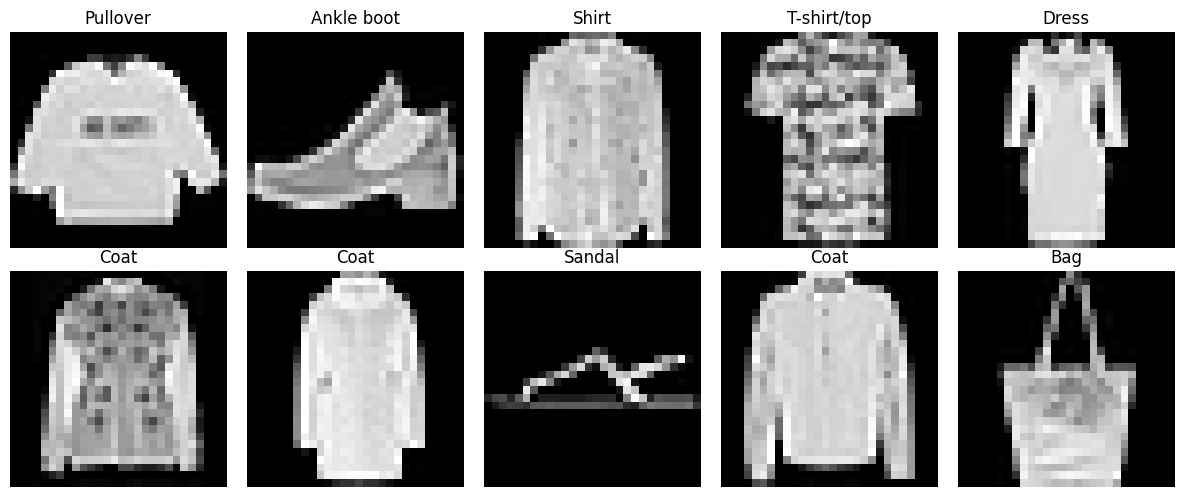

In [25]:
# Plot first 10 images

X_train = df.drop("label", axis=1)
X = X_train.values

y = df["label"].values

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(class_names[y[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()


### Distribución de clases

La distribución de las clases es equilibrada, ya que cada una de las 10 categorías contiene 6000 imágenes. Esto significa que no existe un desbalance entre las clases del conjunto de datos, por lo que todas las categorías tienen la misma representación y no es necesario aplicar técnicas de balanceo de clases.


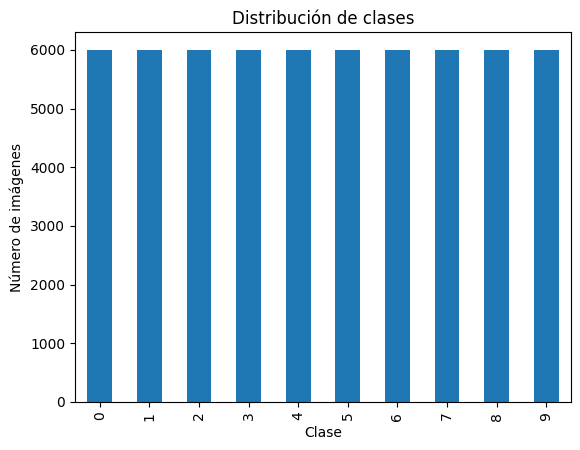

label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000


In [26]:
# Distribución de clases

df["label"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.title("Distribución de clases")
plt.show()

print(df["label"].value_counts().sort_index().to_string())

### Missing values

No se encontraron valores nulos en el conjunto de datos. Esto indica que todas las imágenes cuentan con información en sus atributos de píxeles y que no es necesario realizar un proceso de imputación de valores faltantes.


In [27]:
print("Missing values:", df.isnull().sum().sum())


Missing values: 0


### Registros duplicados

Se encontraron 43 registros duplicados, filas completas idénticas mismos 784 píxeles y misma etiqueta, equivalentes aproximadamente al 0,072 % del conjunto de entrenamiento. Debido a su baja proporción, se reportan como parte del análisis de calidad de los datos sin eliminarlos automáticamente.


In [28]:
duplicados = df.duplicated().sum()
total = len(df)

print("Duplicados:", duplicados)
print("Porcentaje:", (duplicados / total) * 100)

Duplicados: 43
Porcentaje: 0.07166666666666667


### Estadísticas de los píxeles

La intensidad de los píxeles se encuentran entre 0 y 255, donde 0 representa ausencia de intensidad y 255 corresponde a la máxima intensidad. La media de 72.96 indica que, en promedio, los píxeles presentan una intensidad relativamente baja. Esto es coherente el dataset de Fashion-MNIST, ya que las prendas suelen estar representadas sobre un fondo oscuro. La desviación estándar de 89.97 muestra una dispersión considerable en los valores de intensidad, lo que indica que existe una diferencia importante entre las zonas oscuras y las zonas que contienen información visual de las prendas. No se identifican valores fuera del rango esperado, dado que el mínimo es 0 y el máximo 255.


In [29]:
print("Mean: ", X.mean())
print("Std: ", X.std())
print("Min: ", X.min())
print("Max: ", X.max())
print("% de píxeles en 0:", (X == 0).mean() * 100)


Mean:  72.9568306122449
Std:  89.9668629851211
Min:  0
Max:  255
% de píxeles en 0: 50.17988732993197


### Distribución de intensidades

La distribución de intensidades muestra valores entre 0 y 255. Se usa escala logarítmica en el eje Y porque los píxeles en 0 (fondo) dominan de forma tan abrumadora al resto que, en escala lineal, el resto de la distribución se aplana y no se aprecia. El porcentaje de píxeles en 0 se reporta arriba de forma explícita en vez de inferirlo visualmente del histograma.


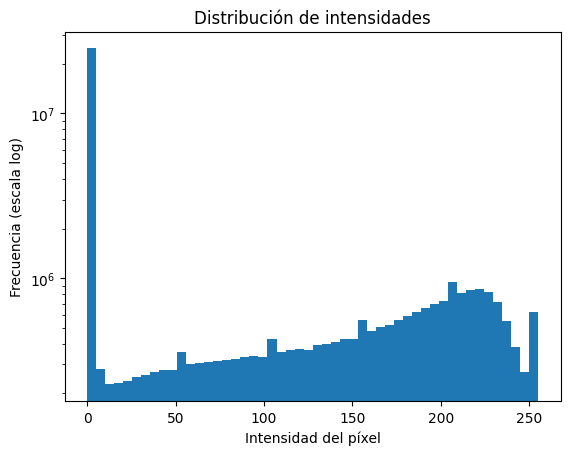

In [30]:
plt.hist(X.flatten(), bins=50)
plt.yscale("log")
plt.xlabel("Intensidad del píxel")
plt.ylabel("Frecuencia (escala log)")
plt.title("Distribución de intensidades")
plt.show()

## Análisis multivariado

Dos vistas multivariadas, ambas en el espacio original de 784 píxeles (no solo en las 2 componentes de PCA, que se analizan aparte más abajo): la imagen promedio por clase, y qué tan correlacionadas están esas imágenes promedio entre sí. Una correlación alta entre dos clases es evidencia directa de que sus siluetas se parecen.


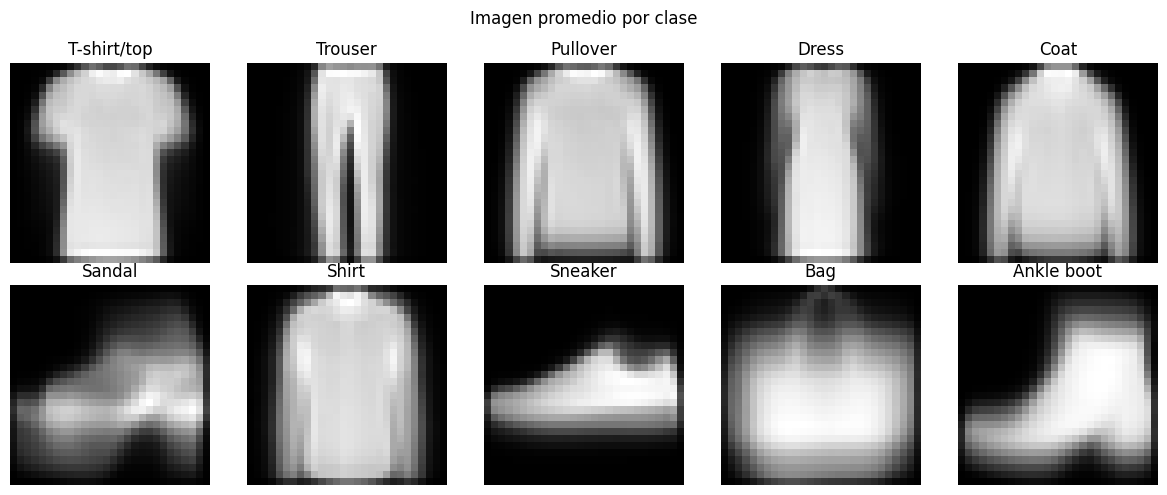

In [31]:
mean_images = np.array([X[y == c].mean(axis=0) for c in range(10)])

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(mean_images[i].reshape(28, 28), cmap="gray")
    ax.set_title(class_names[i])
    ax.axis("off")
plt.suptitle("Imagen promedio por clase")
plt.tight_layout()
plt.show()


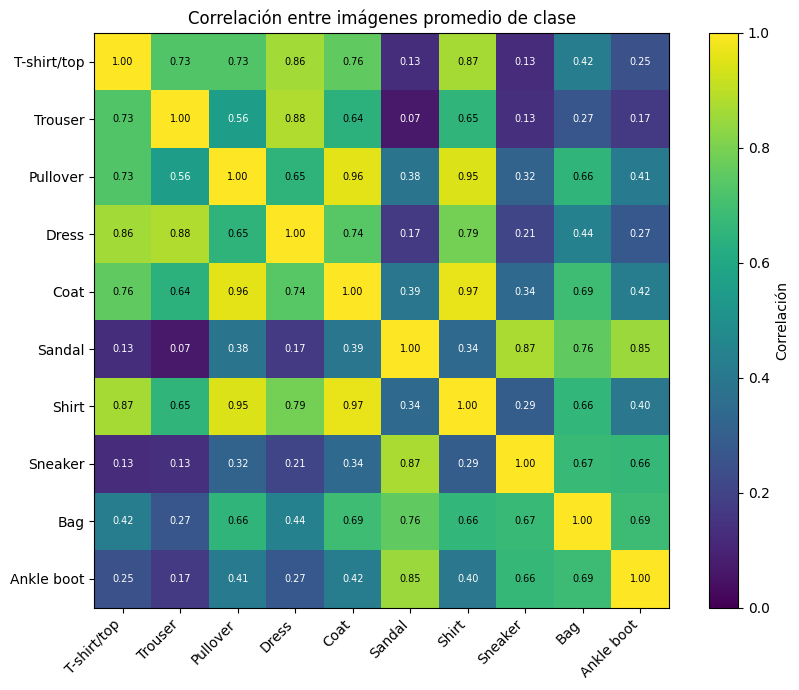

Par de clases más correlacionado (excluyendo diagonal): Coat - Shirt (r=0.97)


In [32]:
corr_matrix = np.corrcoef(mean_images)
corr_df = pd.DataFrame(
    corr_matrix,
    index=[class_names[i] for i in range(10)],
    columns=[class_names[i] for i in range(10)],
)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([class_names[i] for i in range(10)], rotation=45, ha="right")
ax.set_yticklabels([class_names[i] for i in range(10)])
for i in range(10):
    for j in range(10):
        ax.text(
            j,
            i,
            f"{corr_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if corr_matrix[i, j] < 0.6 else "black",
            fontsize=7,
        )
plt.colorbar(im, label="Correlación")
plt.title("Correlación entre imágenes promedio de clase")
plt.tight_layout()
plt.show()

np.fill_diagonal(corr_matrix, np.nan)
max_idx = np.unravel_index(np.nanargmax(corr_matrix), corr_matrix.shape)
print(
    f"Par de clases más correlacionado (excluyendo diagonal): "
    f"{class_names[max_idx[0]]} - {class_names[max_idx[1]]} "
    f"(r={corr_matrix[max_idx]:.2f})"
)


La matriz muestra que `Coat`, `Pullover` y `Shirt` son, en promedio, las clases con mayor correlación entre sí (imágenes promedio muy parecidas), lo cual es consistente con que son prendas superiores de silueta similar. `Sandal` y `Sneaker` se correlacionan alto entre sí pero bajo con las prendas superiores, como es esperable por ser calzado.


## Preprocesamiento y reducción


### Normalización

Las imágenes se normalizan dividiendo los valores de intensidad de los píxeles entre 255, transformando el rango original de 0–255 al rango [0, 1]. Esto facilita el procesamiento numérico y proporciona una representación más adecuada para aplicar técnicas de aprendizaje automático como PCA.


In [34]:
X = X / 255.0

In [35]:
print("NaN en X tras normalizar:", np.isnan(X).sum())
print("Inf en X tras normalizar:", np.isinf(X).sum())
print("Rango de X:", X.min(), "-", X.max())

NaN en X tras normalizar: 0
Inf en X tras normalizar: 0
Rango de X: 0.0 - 1.0


### Aplicación PCA

Utilizamos PCA con 2 componentes para la visualización, permitiendo observar la distribución y posible separación de las clases en un plano.


In [48]:
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X)

print("Shape de X_pca_2:", X_pca_2.shape)
print("Varianza explicada por PC1:", pca_2.explained_variance_ratio_.sum())

Shape de X_pca_2: (60000, 2)
Varianza explicada por PC1: 0.46739021811511416


#### PCA en 2 componentes

Las clases `Shirt`, `T-shirt/top`, `Pullover` y `Coat` presentan un mayor solapamiento en la representación de las dos primeras componentes principales, lo que indica que sus características visuales son similares y no se separan claramente en este espacio reducido. Por otro lado, `Sneaker` y `Trouser` presentan agrupamientos más definidos y una mayor separación respecto a otras clases.

Esto evidencia que las dos primeras componentes principales permiten visualizar parte de la estructura del conjunto de datos, aunque representan solamente una fracción de la información contenida en las 784 características originales.


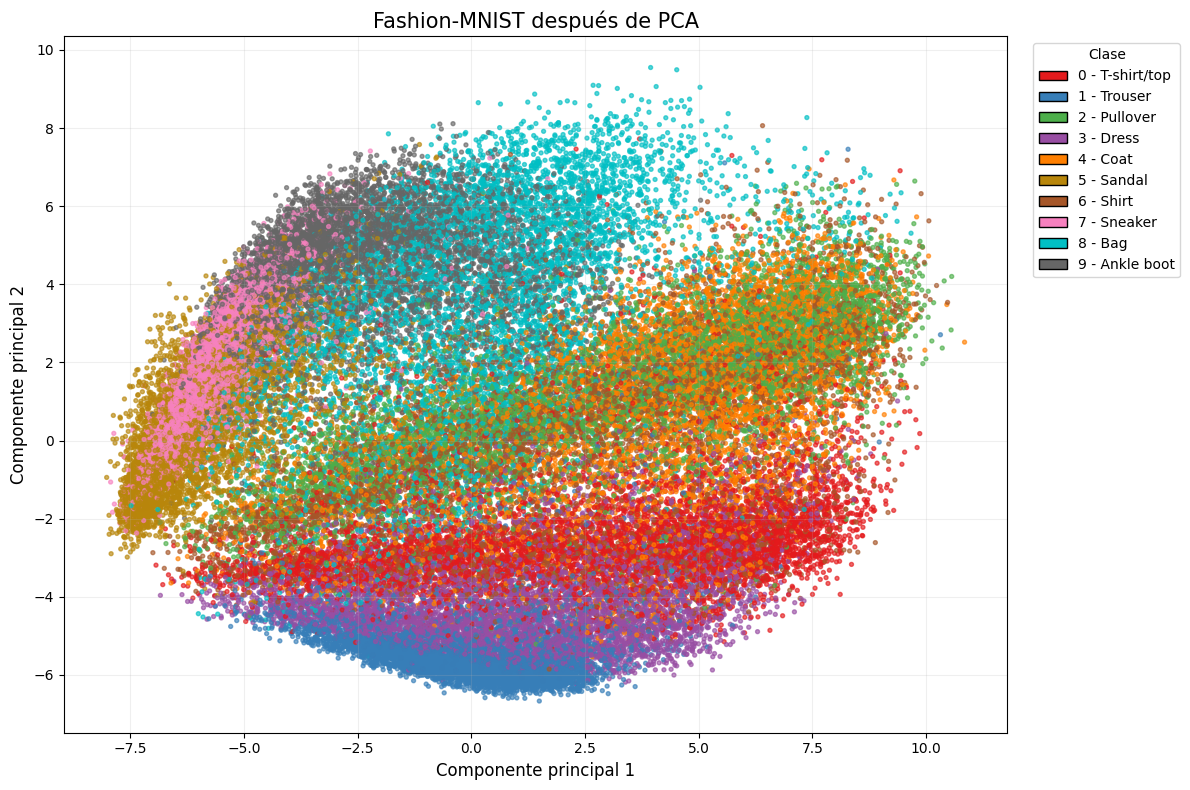

In [49]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Colores claramente diferenciados para las 10 clases
colors = [
    "#e41a1c",  # 0 - Rojo
    "#377eb8",  # 1 - Azul
    "#4daf4a",  # 2 - Verde
    "#984ea3",  # 3 - Morado
    "#ff7f00",  # 4 - Naranja
    "#b8860b",  # 5 - Dorado oscuro
    "#a65628",  # 6 - Café
    "#f781bf",  # 7 - Rosado
    "#00bfc4",  # 8 - Turquesa
    "#666666",  # 9 - Gris
]


cmap = ListedColormap(colors)

# Gráfico PCA
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap=cmap, vmin=0, vmax=9, s=8, alpha=0.65
)

plt.xlabel("Componente principal 1", fontsize=12)
plt.ylabel("Componente principal 2", fontsize=12)
plt.title("Fashion-MNIST después de PCA", fontsize=15)

# Crear leyenda auxiliar
legend_elements = [
    Patch(facecolor=colors[i], edgecolor="black", label=f"{i} - {class_names[i]}")
    for i in range(10)
]

plt.legend(
    handles=legend_elements, title="Clase", bbox_to_anchor=(1.02, 1), loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


#### Varianza explicada por PCA

Mediante PCA se redujo la dimensionalidad de las imágenes de 784 características originales a 187 componentes principales, conservando aproximadamente el 95 % de la varianza. Esto permite reducir considerablemente la cantidad de características y mantener la mayor parte de la variabilidad presente en los datos.


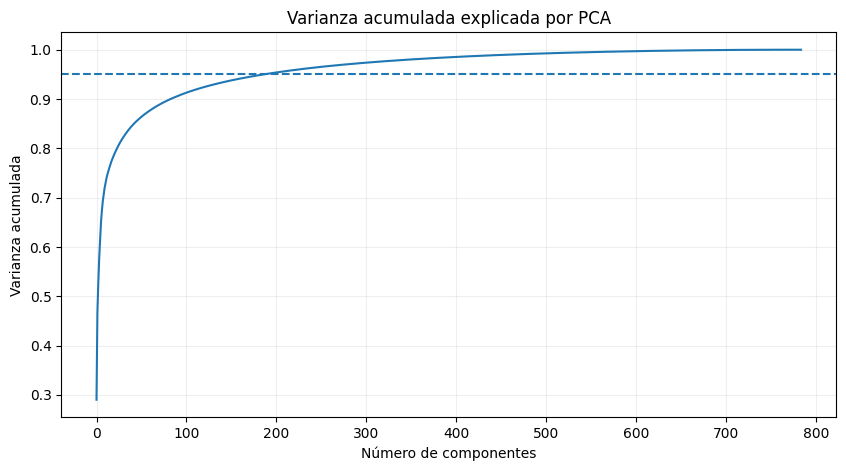

In [40]:
pca = PCA()
pca.fit(X)

varianza_acumulada = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(10, 5))
plt.plot(varianza_acumulada)
plt.axhline(y=0.95, linestyle="--")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada explicada por PCA")
plt.grid(alpha=0.2)
plt.show()

In [41]:
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X)

print("Numero de componentes:", X_pca_95.shape[1])

Numero de componentes: 187
